# Pendulum Single Model Training

This notebook demonstrates:
1. Generating synthetic pendulum data
2. Training a single LFADS model
3. Analyzing and visualizing the results

In [ ]:
# Import required libraries
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import pickle
import yaml
import importlib

# Add src to path if needed
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'src'))

import lfadsci
import lfadsci.run_utils
import lfadsci.shared_utils
import lfadsci.model
import lfadsci.utils_pendulum

# Enable inline plotting
%matplotlib inline

## 1. Set Configuration Parameters

Define the model and training parameters for the pendulum task.

In [ ]:
# Set random seed for reproducibility
seed = 98
np.random.seed(seed)

# Configuration parameters (matched to scripts/pendulum_single_fit.sh)
config = {
    'seed': seed,
    'data_seed': seed,
    'batch_size': 512,
    'train_frac': 0.6,
    'val_frac': 0.2,
    'test_frac': 0.2,
    'outputDir': os.path.abspath(os.path.join(os.getcwd(), '..', 'models')),
    'mode': 'train',

    # Training parameters (script uses config defaults for these)
    'lr_init': 1e-4,
    'lr_stop': 1e-6,
    'n_steps': 40000,
    'decay_factor': 0.95,
    'patience_till_lr_decay': 10,
    'save_freq': 500,

    # Dataset configuration
    'dataset': {
        'name': 'pendulum'
    },

    # Model configuration
    'model': {
        'factors': 40,
        'ic_dim': 5,
        'bias_dim': 5,
        'n_hidden_encode_ic': 128,
        'n_hidden_encode_bias': 128,
        'n_hidden_encode_tv_input': 128,
        'n_hidden_decode': 200,
        'n_dynamics': 1,
        'dropout_rate': 0.0,
        'lam_predict': 1.0,
        'lam_kl_ic': 1.0,
        'lam_kl_bias': 1.0,
        'lam_kl_tv_inp': 1.0,
        'lam_l2': 0,
        'tv_input_dim': 1,
        'tv_input_smoothness_alpha': 0.0,
        'noise_stddev': 0.0,
        'generator_type': 'gru',
        'use_bias': True,
        'use_tv_input': False,
        'kl_warmup_start': 500,
        'kl_warmup_end': 1000,
    }
}

# Create output directory
os.makedirs(config['outputDir'], exist_ok=True)

print("Configuration set successfully!")
print(f"Output directory: {config['outputDir']}")

Configuration set successfully!
Output directory: /home/user/users/nishalps/git/lfadsci/models


## 2. Generate Pendulum Data

Generate synthetic neural data from pendulum dynamics with different gravity values.

Generating pendulum data...
............................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................

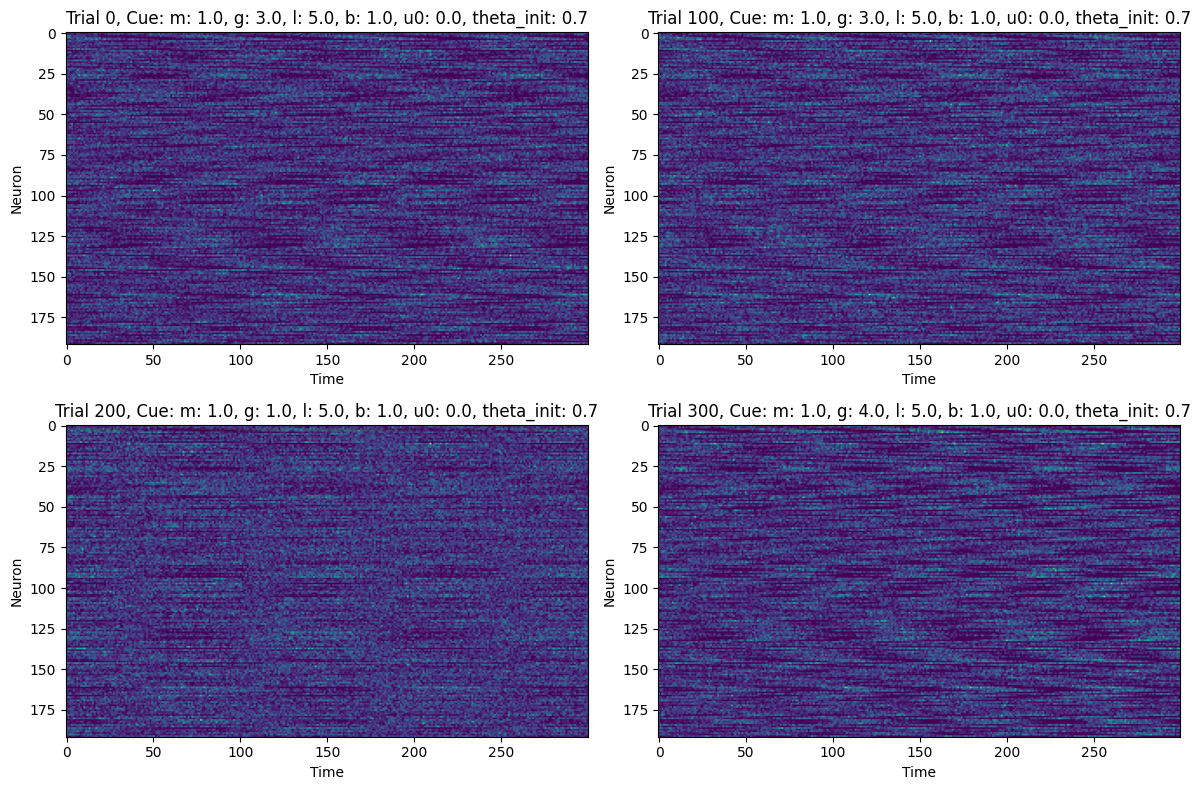

In [10]:
# Generate pendulum data
print("Generating pendulum data...")
neural_trials, cues_trials, delays_trials, session_trials = lfadsci.utils_pendulum.get_data(
    n_trials_total=1000,
    theta_init_randomize=False,
    b_randomize=False,
    g_randomize=True
)

print(f"Data shape: {neural_trials.shape}")
print(f"Number of trials: {len(neural_trials)}")
print(f"Time steps per trial: {neural_trials.shape[1]}")
print(f"Number of neurons: {neural_trials.shape[2]}")

# Visualize sample trials
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(neural_trials[i*100].T, aspect='auto', cmap='viridis')
    ax.set_xlabel('Time')
    ax.set_ylabel('Neuron')
    cues = cues_trials[i*100].split(',')
    ax.set_title(f'Trial {i*100}, Cue: m: {cues[0]}, g: {cues[1]}, l: {cues[2]}, b: {cues[3]}, u0: {cues[4]}, theta_init: {cues[5]}')
plt.tight_layout()
plt.show()

## 3. Prepare Data for Training

Split data into train/validation/test sets and create data generators.

In [11]:
# Prepare data using the shared utilities
print("Preparing data generators...")

data_list = [{
    'neural': neural_trials,
    'cues': cues_trials,
    'delays': delays_trials,
    'session_id': session_trials,
    'task': 'pendulum'
}]

datagenerator_combined, datasets_list = lfadsci.shared_utils.combine_datasets(
    data_list,
    batch_sz=config['batch_size'],
    train_frac=config['train_frac'],
    val_frac=config['val_frac'],
    test_frac=config['test_frac'],
    seed=config['data_seed'],
    data_weight=[1.0]
)

data = {
    'datagenerator': datagenerator_combined,
    'datasets': datasets_list,
    'data_val_weight': [1.0]
}

print(f"Training trials: {len(datasets_list[0]['train']['neural'])}")
print(f"Validation trials: {len(datasets_list[0]['eval']['neural'])}")
print(f"Test trials: {len(datasets_list[0]['test']['neural'])}")

n_channels = [dataset['train']['neural'].shape[-1] for dataset in data['datasets']]
print(f"Number of channels: {n_channels}")

Preparing data generators...
Original data weights: [1.0]
Rescaled data weights: [1.] to account for  different number of samples accross datasets.
Number of repeats per dataset: [100]
Repeating data 0: 100 times
Repeating data 0: 100 times
Repeating data 0: 100 times
Training trials: 600
Validation trials: 200
Test trials: 201
Number of channels: [192]


## 4. Build and Train LFADS Model

Create the LFADS model and train it on the pendulum data.

You can also fit the model from the command line using the shell script `scripts/pendulum_single_fit.sh`.

In [12]:
# Import TensorFlow and set seed
import tensorflow as tf
tf.random.set_seed(config['seed'])

print(f"TensorFlow version: {tf.__version__}")
print("Building LFADS model...")

# Load model from configuration
model = lfadsci.model.load_model_from_config(
    config,
    n_channels,
    model_filename=f"{config['outputDir']}/model"
)

print("Model built successfully!")
print(f"Model will be saved to: {config['outputDir']}/model")

TensorFlow version: 2.11.0
Building LFADS model...
Building initial condition encoder
Building bias encoder
mu_phi (None, 5) sig_phi (None, 5)
Model loaded
Model built successfully!
Model will be saved to: /home/user/users/nishalps/git/lfadsci/models/model


In [ ]:
# Train the model
print("Starting training...")
print(f"Training for {config['n_steps']} steps")

import time
start_time = time.time()

loss_np = lfadsci.run_utils.train(
    data['datagenerator']['train'],
    model,
    data_test=[d['eval'] for d in data['datasets']],
    lr_init=config['lr_init'],
    lr_stop=config['lr_stop'],
    lams=None,
    n_steps=config['n_steps'],
    to_plot=False,
    kl_warmup_start=[config['model']['kl_warmup_start']],
    kl_warmup_end=[config['model']['kl_warmup_end']],
    decay_factor=config['decay_factor'],
    gradient_clipping_norm=0.1,
    savefile=f"{config['outputDir']}/model",
    n_eval_samples=None,
    patience_till_lr_decay=config['patience_till_lr_decay'],
    save_freq=config['save_freq'],
    data_val_weight=data['data_val_weight']
)

training_time = time.time() - start_time
print(f"Training completed in {training_time:.2f} seconds ({training_time/60:.2f} minutes)")

# Plot training loss
plt.figure(figsize=(10, 4))
plt.plot(loss_np)
plt.xlabel('Training Step')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.grid(True)
plt.show()

## 5. Load Trained Model and Generate Results

Load the trained model checkpoint and generate posterior samples.

In [15]:
# Load the trained model
print("Loading trained model...")
model.load(f"{config['outputDir']}/model")
print("Model loaded successfully!")

# Load cached results if available; otherwise compute
results_partial_path = os.path.join(config['outputDir'], 'results_partial.pkl')
results_full_path = os.path.join(config['outputDir'], 'results_full.pkl')

if os.path.exists(results_full_path):
    print(f"Found cached full results: {results_full_path}")
    with open(results_full_path, 'rb') as f:
        loaded = pickle.load(f)
    results = loaded['results_list'][0] if isinstance(loaded, dict) and 'results_list' in loaded else loaded
elif os.path.exists(results_partial_path):
    print(f"Found cached partial results: {results_partial_path}")
    with open(results_partial_path, 'rb') as f:
        loaded = pickle.load(f)
    results = loaded['results_list'][0] if isinstance(loaded, dict) and 'results_list' in loaded else loaded
else:
    print("No cached results found. Generating results with posterior sampling...")
    results = lfadsci.shared_utils.compile_results(
        model,
        datasets_list[0],
        n_samples=100,
        compute_kinematic_r2=False
    )

print("Results ready!")
print(f"Available partitions: {list(results.keys())}")
print(f"Available features in 'train': {list(results['train'].keys())}")

Loading trained model...
Model loaded successfully!
Found cached full results: /home/user/users/nishalps/git/lfadsci/models/results_full.pkl
Results ready!
Available partitions: ['train', 'eval', 'test']
Available features in 'train': ['ic_sample', 'ic_mu', 'ic_sig', 'firing_rate', 'factors', 'factors_stacked', 'states_stacked', 'bias_sample', 'bias_mu', 'bias_sig', 'state', 'metrics', 'fixed_points', 'fixed_points_filtered', 'fixed_point_speeds', 'fixed_points_filtered_speeds', 'jacobians']


## 6. Fixed Point Analysis

Perform fixed point finding and eigenvalue analysis.

In [17]:
# Load cached full fixed-point results if available; otherwise run analysis
results_full_path = os.path.join(config['outputDir'], 'results_full.pkl')

if os.path.exists(results_full_path):
    print(f"Found cached full results: {results_full_path}")
    with open(results_full_path, 'rb') as f:
        loaded = pickle.load(f)
    results = loaded['results_list'][0] if isinstance(loaded, dict) and 'results_list' in loaded else loaded
    print("Loaded fixed-point analysis results from cache.")
else:
    print("Running fixed point analysis...")

    for partition in ['train', 'test', 'eval']:
        session_id = np.array(datasets_list[0][partition]['session'][0, 0])
        print(f'Running fixed point finding for partition: {partition}')

        results = lfadsci.shared_utils.complete_fixed_point_analysis(
            model,
            results,
            EPS1=1e-7,
            get_fixed_points_only=False,
            partition=partition,
            to_plot=False,
            session_id=session_id
        )

    print("Fixed point analysis completed!")

    # Save results
    pickle.dump(
        {'results_list': [results]},
        open(results_full_path, 'wb')
    )
    print(f"Results saved to {results_full_path}")

Found cached full results: /home/user/users/nishalps/git/lfadsci/models/results_full.pkl
Loaded fixed-point analysis results from cache.


## 7. Visualize Results

Plot the learned representations and dynamics.

In [18]:
# Extract cues (gravity values) for visualization
partition_use = 'train'
datasets = datasets_list[0]
cues = np.array([float(c.split(',')[1]) for c in datasets[partition_use]['cues']])

print(f"Number of conditions (unique gravity values): {len(np.unique(cues))}")
print(f"Gravity values: {sorted(np.unique(cues))}")

Number of conditions (unique gravity values): 8
Gravity values: [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0]


Number of trials with fixed-point entries: 600
Number of fixed points found: 600


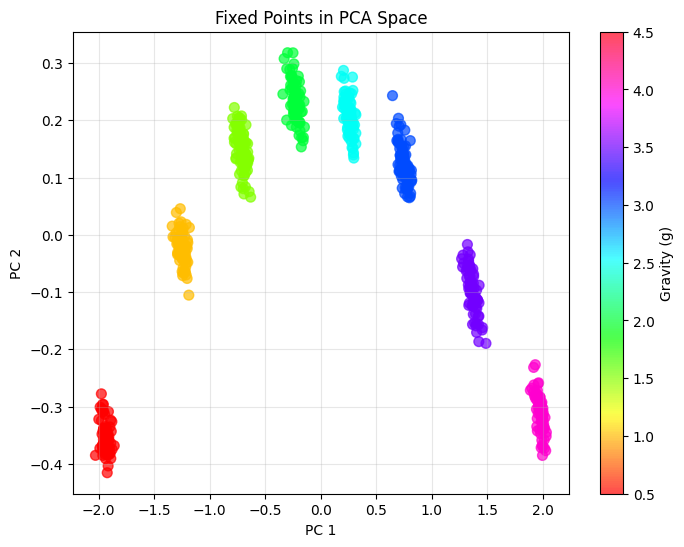

In [20]:
# Visualize fixed points in PCA space
from sklearn.decomposition import PCA

# Get fixed points
if 'fixed_points_filtered' in results['train'].keys():
    fixed_points_by_trial = results['train']['fixed_points_filtered']
    print(f"Number of trials with fixed-point entries: {len(fixed_points_by_trial)}")

    # Flatten fixed points and keep trial-aligned cues
    fp_locations = []
    fp_cues = []

    for trial_idx, fps_trial in enumerate(fixed_points_by_trial):
        if fps_trial is None or len(fps_trial) == 0:
            continue

        for fp in fps_trial:
            # Support both dict-based and array-based fixed-point formats
            if isinstance(fp, dict) and 'x' in fp:
                loc = np.asarray(fp['x'])
            else:
                loc = np.asarray(fp)

            loc = np.squeeze(loc)
            if loc.ndim != 1:
                continue

            fp_locations.append(loc)
            if trial_idx < len(cues):
                fp_cues.append(cues[trial_idx])
            else:
                fp_cues.append(np.nan)

    if len(fp_locations) == 0:
        print("No valid fixed-point vectors found to plot")
    else:
        fp_locations = np.array(fp_locations)
        fp_cues = np.array(fp_cues)
        print(f"Number of fixed points found: {len(fp_locations)}")

        # PCA projection
        pca = PCA(n_components=2)
        fp_2d = pca.fit_transform(fp_locations)

        # Plot
        plt.figure(figsize=(8, 6))
        scatter = plt.scatter(
            fp_2d[:, 0], fp_2d[:, 1],
            c=fp_cues, cmap='hsv', s=50,
            vmin=0.5, vmax=4.5, alpha=0.7
        )
        plt.colorbar(scatter, label='Gravity (g)')
        plt.xlabel('PC 1')
        plt.ylabel('PC 2')
        plt.title('Fixed Points in PCA Space')
        plt.grid(True, alpha=0.3)
        plt.show()
else:
    print("No fixed points found in results")

Plotting neural trajectories...
State shape: (600, 300, 200)
ERROR:tensorflow:==================================
Object was never used (type <class 'tensorflow.python.ops.tensor_array_ops.TensorArray'>):
If you want to mark it as used call its "mark_used()" method.
It was originally created here:
  File "/home/user/miniconda3/envs/lfads_gpu/lib/python3.9/site-packages/keras/backend.py", line 5133, in <genexpr>
    ta.write(ta_index_to_write, out)  File "/home/user/miniconda3/envs/lfads_gpu/lib/python3.9/site-packages/tensorflow/python/util/tf_should_use.py", line 243, in wrapped
    return _add_should_use_warning(fn(*args, **kwargs),


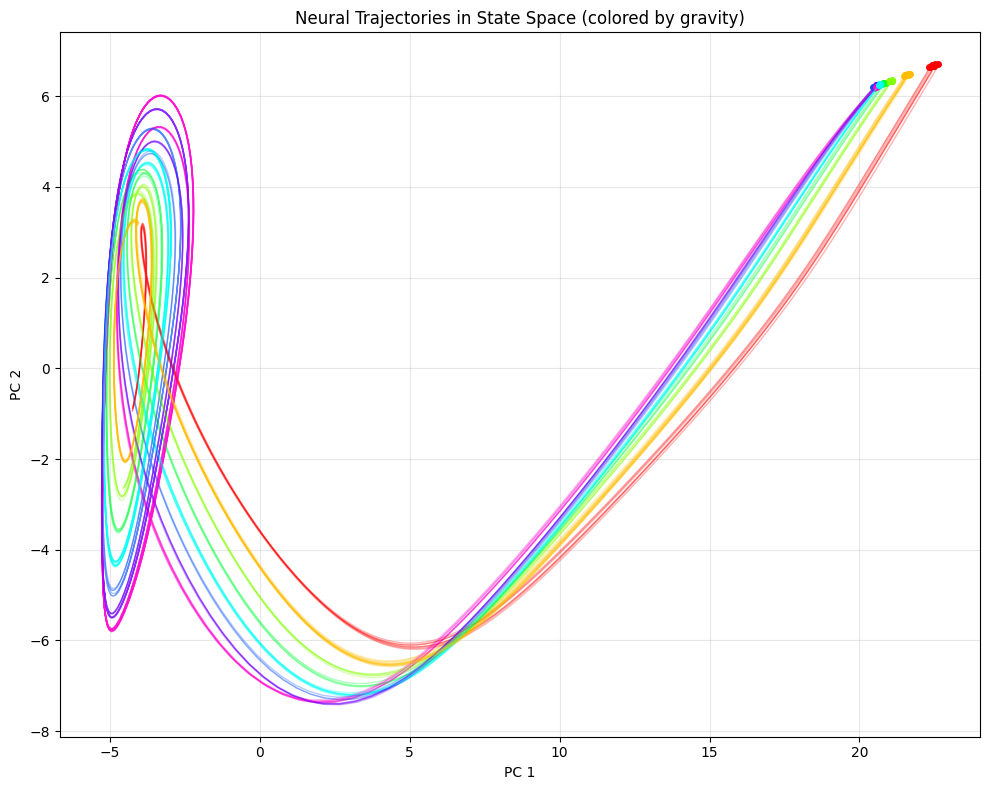

In [21]:
# Plot neural trajectories in state space
print("Plotting neural trajectories...")

# Get states for a subset of trials
states = results['train']['state']
print(f"State shape: {states.shape}")

# Project to PCA space
n_trials_plot = 50
states_subset = states[:n_trials_plot, :, :]
states_2d_all = states_subset.reshape(-1, states_subset.shape[-1])

pca = PCA(n_components=2)
states_2d = pca.fit_transform(states_2d_all)
states_2d = states_2d.reshape(n_trials_plot, states_subset.shape[1], 2)

# Plot trajectories colored by gravity
fig, ax = plt.subplots(figsize=(10, 8))

for i in range(n_trials_plot):
    g_val = cues[i]
    color = plt.cm.hsv((g_val - 0.5) / 4.0)
    ax.plot(states_2d[i, :, 0], states_2d[i, :, 1], 
           color=color, alpha=0.3, linewidth=1)
    ax.plot(states_2d[i, 0, 0], states_2d[i, 0, 1], 
           'o', color=color, markersize=4)

plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.title('Neural Trajectories in State Space (colored by gravity)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Visualizing bias samples...
Bias samples shape: (600, 5)


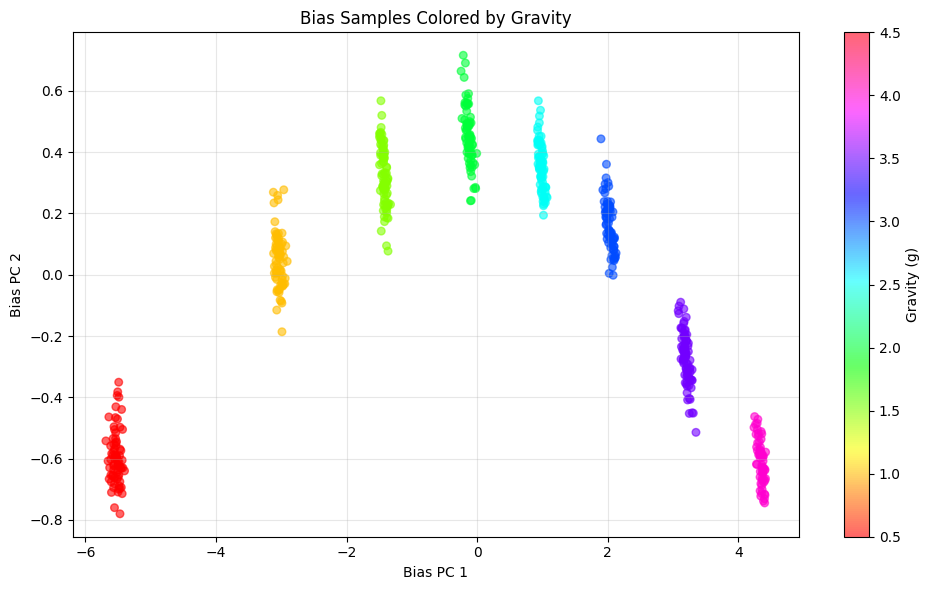

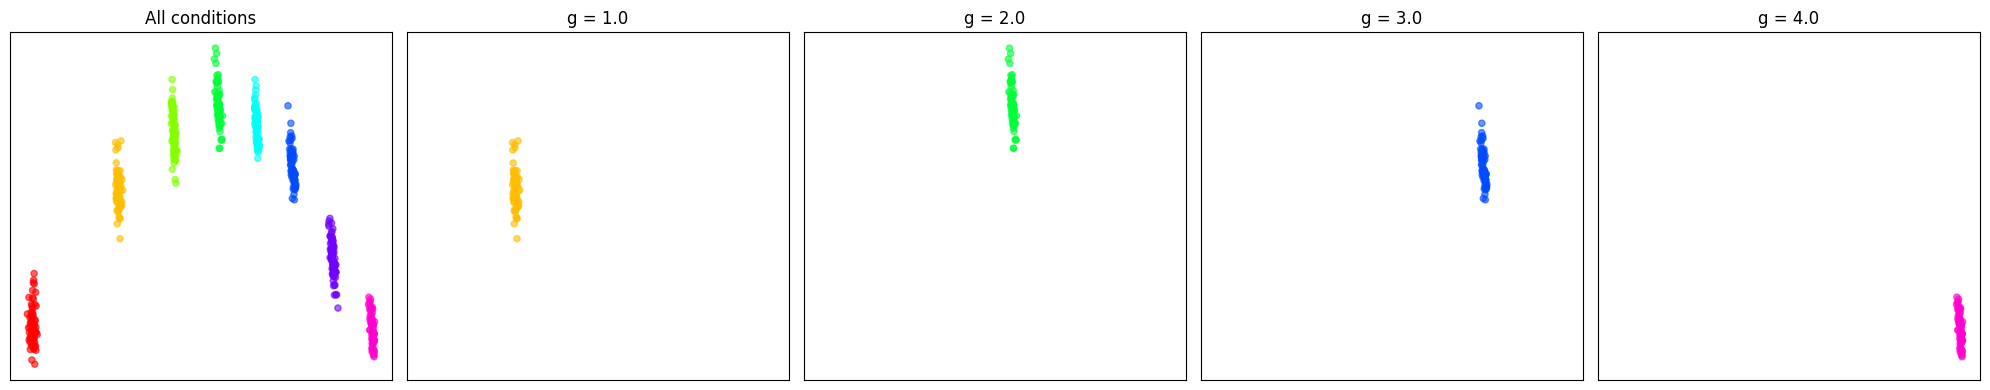

In [22]:
# Visualize bias samples (if using bias model)
if config['model']['use_bias'] and 'bias_sample' in results['train'].keys():
    print("Visualizing bias samples...")
    
    bias_samples = results['train']['bias_sample']
    print(f"Bias samples shape: {bias_samples.shape}")
    
    # PCA on bias samples
    pca_bias = PCA(n_components=2)
    bias_2d = pca_bias.fit_transform(bias_samples)
    
    plt.figure(figsize=(10, 6))
    
    # Plot all gravity values
    scatter = plt.scatter(bias_2d[:, 0], bias_2d[:, 1], 
                         c=cues, cmap='hsv', s=30, alpha=0.6,
                         vmin=0.5, vmax=4.5)
    plt.colorbar(scatter, label='Gravity (g)')
    plt.xlabel('Bias PC 1')
    plt.ylabel('Bias PC 2')
    plt.title('Bias Samples Colored by Gravity')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Plot by specific gravity values
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    
    for iidx, (ax, g_val) in enumerate(zip(axes.flat, [None, 1.0, 2.0, 3.0, 4.0])):
        if g_val is None:
            idx_plot = np.arange(bias_2d.shape[0])
            title = 'All conditions'
        else:
            idx_plot = np.where(np.abs(cues - g_val) < 0.1)[0]
            title = f'g = {g_val}'
        
        if iidx == 0:
            # Get limits from first plot
            scatter = ax.scatter(bias_2d[idx_plot, 0], bias_2d[idx_plot, 1],
                               c=cues[idx_plot], cmap='hsv', s=20, alpha=0.6,
                               vmin=0.5, vmax=4.5)
            xlim = ax.get_xlim()
            ylim = ax.get_ylim()
        else:
            ax.scatter(bias_2d[idx_plot, 0], bias_2d[idx_plot, 1],
                      c=cues[idx_plot], cmap='hsv', s=20, alpha=0.6,
                      vmin=0.5, vmax=4.5)
            ax.set_xlim(xlim)
            ax.set_ylim(ylim)
        
        ax.set_title(title)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("Bias not used in model or bias_sample not available")

Visualizing initial condition samples...
IC samples shape: (600, 5)


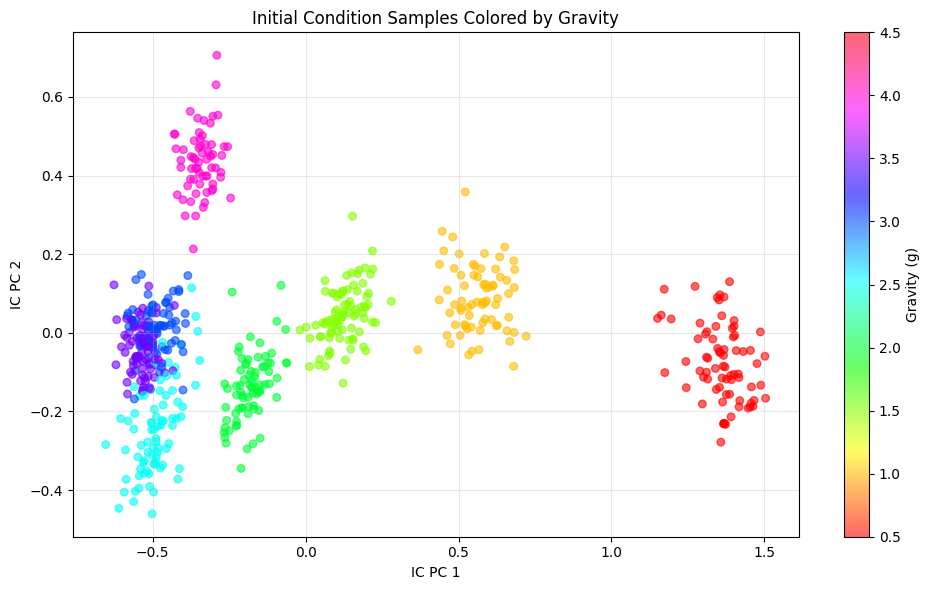

In [23]:
# Plot initial condition samples
if 'ic_sample' in results['train'].keys():
    print("Visualizing initial condition samples...")
    
    ic_samples = results['train']['ic_sample']
    print(f"IC samples shape: {ic_samples.shape}")
    
    # PCA on IC samples
    pca_ic = PCA(n_components=2)
    ic_2d = pca_ic.fit_transform(ic_samples)
    
    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(ic_2d[:, 0], ic_2d[:, 1], 
                         c=cues, cmap='hsv', s=30, alpha=0.6,
                         vmin=0.5, vmax=4.5)
    plt.colorbar(scatter, label='Gravity (g)')
    plt.xlabel('IC PC 1')
    plt.ylabel('IC PC 2')
    plt.title('Initial Condition Samples Colored by Gravity')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

Performing eigenvalue analysis...


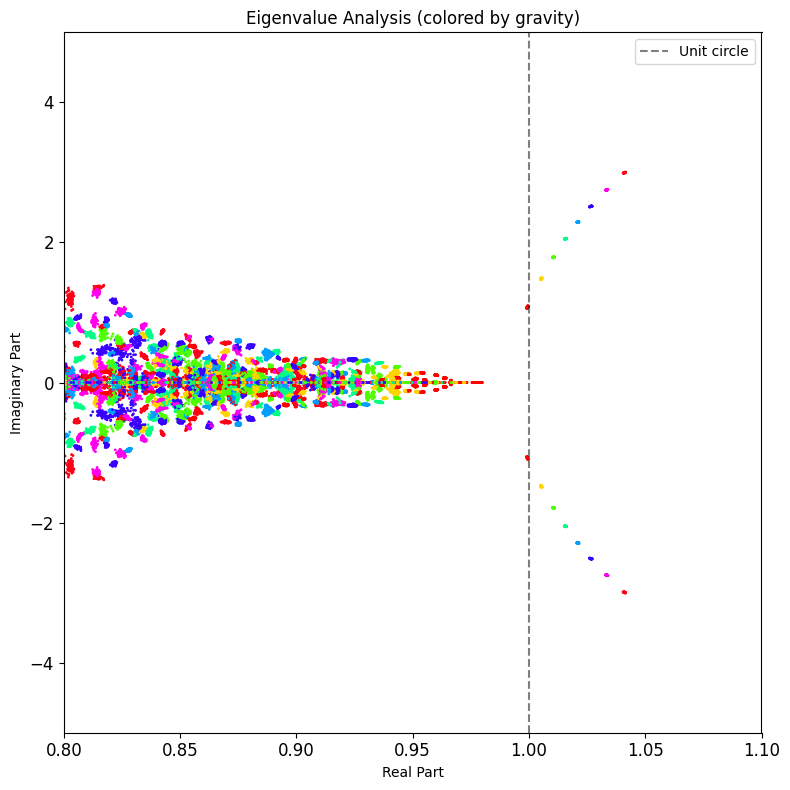

In [24]:
# Eigenvalue analysis
if 'jacobians' in results['train'].keys():
    print("Performing eigenvalue analysis...")
    
    # Use the utility function from utils_pendulum
    fig, ax = plt.subplots(figsize=(8, 8))
    
    lfadsci.utils_pendulum.ev_plot_pendulum(
        datasets_list[0],
        results,
        ax=ax,
        sz_scale=1,
        movement_colors=True,
        cmap='hsv'
    )
    
    ax.set_xlim([0.8, 1.1])
    ax.set_ylim([-5, 5])
    ax.set_xlabel('Real Part')
    ax.set_ylabel('Imaginary Part')
    ax.set_title('Eigenvalue Analysis (colored by gravity)')
    ax.axvline(1.0, color='k', linestyle='--', alpha=0.5, label='Unit circle')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Jacobians not available in results")

Creating 3D visualization...


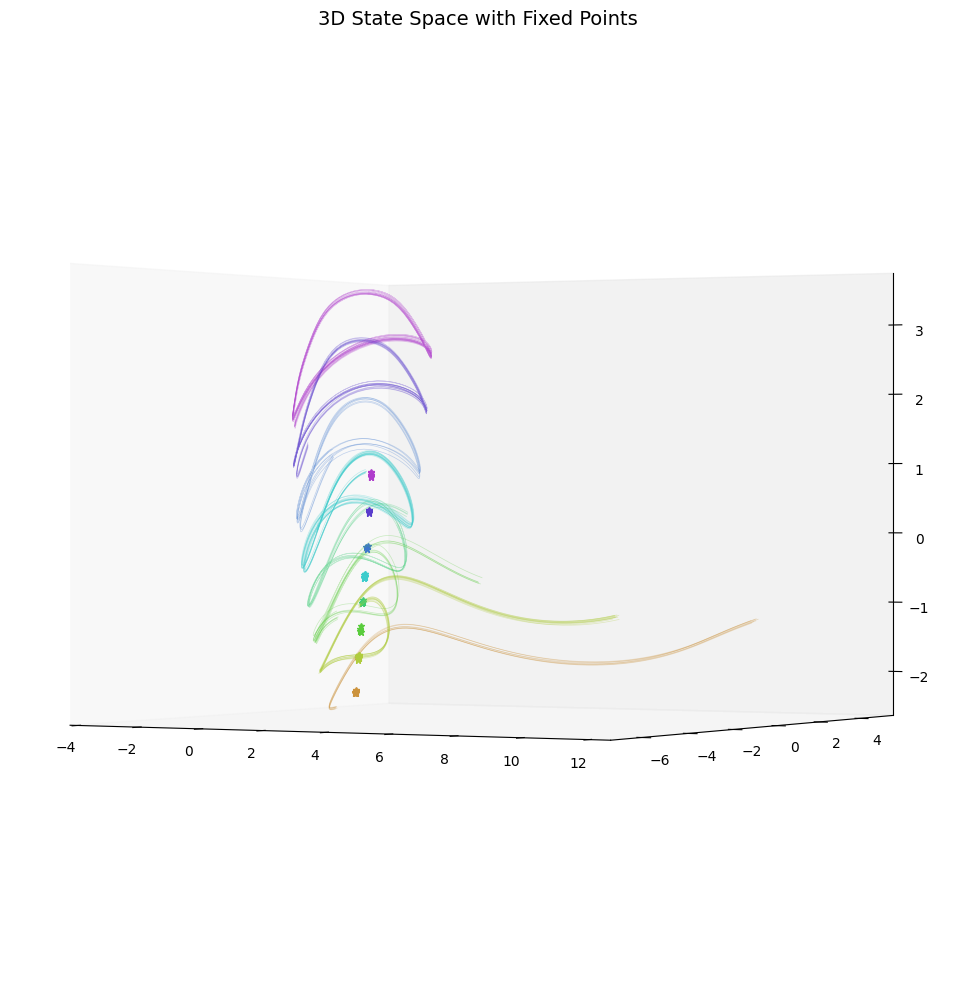

In [26]:
# 3D visualization of states and fixed points
if 'fixed_points_filtered' in results['train'].keys():
    print("Creating 3D visualization...")
    
    # Get states starting from timestep 100 onwards
    states_subset = states[:50, 100:, :]
    
    lfadsci.utils_pendulum.plot_states_fps(
        cues[:50],
        states_subset,
        results['train']['fixed_points_filtered'],
        n_comps_cis=2,
        elev=0,
        azim=-60,
        alpha_state=0.3,
        alpha_fp=1,
        color_fixedpoints=config['model']['use_bias'],
        fp_marker='*',
        fp_markersize=5,
        state_lw=0.5,
        add_cis_dimension=True
    )
    
    plt.suptitle('3D State Space with Fixed Points', fontsize=14)
    plt.tight_layout()
    plt.show()

## 8. Summary

The notebook has successfully:
1. ✓ Generated synthetic pendulum data with varying gravity values
2. ✓ Trained an LFADS model on the data
3. ✓ Performed fixed point analysis
4. ✓ Visualized the learned representations

The model learns to represent different pendulum dynamics (gravity values) through:
- Distinct fixed points for each condition
- Bias vectors that capture context-dependent dynamics
- Smooth trajectories in latent space